# Week 3 Strategic Decision Analysis

**Decision:** For the next 90 days, should the business prioritize UK customer retention and development, international expansion, or a staged hybrid approach?

This notebook uses Week 1 and Week 2 outputs to build a decision-ready recommendation. It focuses on evidence, sensitivity checks, and practical next steps rather than forecasting or machine-learning complexity.


## 1. Objective

- Protect and develop the UK customer base through retention, reactivation, and high-potential customer identification.
- Screen international markets using MARACA-style evidence plus concentration and data-quality risk checks.
- Compare strategic options and recommend a staged 90-day approach without inventing an unsupported budget allocation.


In [1]:
# 这里先统一导入本周会用到的包。
# pandas / numpy 负责数据整理和计算，matplotlib / seaborn 负责图表，pathlib 负责可移植路径。
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 表格显示尽量完整，方便检查中间结果和最终结论。
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# 图表风格沿用 Week 2 的简洁风格，避免 notebook 里出现太多不同视觉语言。
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


## 2. Setup and Path Configuration

The notebook discovers the project root from the current working directory. It can run from either the repository root or the `week3` folder without depending on a personal absolute path.


In [2]:
# 定位项目根目录
# -> 查找 Week 1 输入
# -> 创建 Week 3 输出目录
# -> 校验必要文件
CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start_dir):
    # 从当前目录往上找，只要同时发现 week1 和 week2，就认为这里是项目根目录。
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / 'week1').is_dir() and (candidate / 'week2').is_dir():
            return candidate
    raise FileNotFoundError(
        'Could not locate the project root. Run this notebook from the repository root or the week3 folder. '
        f'Current working directory: {start_dir}'
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
WEEK1_ROOT = PROJECT_ROOT / 'week1'
WEEK3_ROOT = PROJECT_ROOT / 'week3'
DATASET_DIR = WEEK1_ROOT / 'Week1_0706' / 'dataset'
FEATURE_DIR = WEEK1_ROOT / 'feature_tables'
OUTPUT_DIR = WEEK3_ROOT / 'outputs'
FORM_OUTPUT_DIR = OUTPUT_DIR / 'forms'
PLOT_OUTPUT_DIR = OUTPUT_DIR / 'plots'

FORM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

file_paths = {
    'cleaned_sales': DATASET_DIR / 'cleaned_sales.csv',
    'order_features': FEATURE_DIR / 'order_features.csv',
    'customer_features': FEATURE_DIR / 'customer_features.csv',
    'product_features': FEATURE_DIR / 'product_features.csv',
    'country_features': FEATURE_DIR / 'country_features.csv',
}

missing_files = [name for name, path in file_paths.items() if not path.exists()]
if missing_files:
    expected_locations = '\n'.join(str(path) for path in file_paths.values())
    raise FileNotFoundError(
        'Missing Week 1 input files: ' + ', '.join(missing_files) + '\n'
        f'Current working directory: {CURRENT_DIR}\n'
        f'Expected locations:\n{expected_locations}'
    )

print('Project root detected successfully.')
print('Week 3 outputs: outputs/')


Project root detected successfully.
Week 3 outputs: outputs/


## 3. Load and Validate Week 1 Outputs

IDs are loaded as strings because they are identifiers rather than numeric measures. `OrderDate` is parsed once at load time so later time-based analysis stays consistent.


In [3]:
# 这里读取 Week 1 清洗后的交易明细表。
# CustomerID / InvoiceNo / StockCode 都是编号字段，直接读成 string 可以避免无意义的类型转换。
cleaned_sales = pd.read_csv(
    file_paths['cleaned_sales'],
    dtype={'CustomerID': 'string', 'InvoiceNo': 'string', 'StockCode': 'string'},
    parse_dates=['OrderDate'],
)

# 这些特征表主要用来验证 Week 1 产物是否完整，同时为后续口径对照提供上下文。
order_features = pd.read_csv(file_paths['order_features'], dtype={'InvoiceNo': 'string', 'CustomerID': 'string'})
customer_features = pd.read_csv(file_paths['customer_features'], dtype={'CustomerID': 'string'})
product_features = pd.read_csv(file_paths['product_features'], dtype={'StockCode': 'string'})
country_features = pd.read_csv(file_paths['country_features'])

required_columns = {
    'cleaned_sales': {'CustomerID', 'InvoiceNo', 'Country', 'StockCode', 'OrderDate', 'Quantity', 'UnitPrice', 'Revenue'},
    'customer_features': {'CustomerID', 'customer_order_count', 'customer_total_revenue'},
    'country_features': {'Country', 'country_total_revenue', 'country_customer_count'},
}
tables = {
    'cleaned_sales': cleaned_sales,
    'customer_features': customer_features,
    'country_features': country_features,
}

validation_rows = []
for table_name, expected_columns in required_columns.items():
    missing = sorted(expected_columns - set(tables[table_name].columns))
    validation_rows.append({
        'table': table_name,
        'required_columns_present': not missing,
        'missing_columns': ', '.join(missing) if missing else '',
    })

input_validation = pd.DataFrame(validation_rows)
if not input_validation['required_columns_present'].all():
    raise ValueError('Required Week 1 columns are missing. Review the validation table before continuing.')

display(input_validation)
print(f'Cleaned sales rows: {len(cleaned_sales):,}')
print(f'Order date range: {cleaned_sales["OrderDate"].min()} to {cleaned_sales["OrderDate"].max()}')


,table,required_columns_present,missing_columns
0,cleaned_sales,True,
1,customer_features,True,
2,country_features,True,


Cleaned sales rows: 392,692
Order date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## 4. Data-Risk Controls

December 2011 is incomplete and is excluded from decision metrics. Bulk orders remain valid sales but are flagged so raw revenue can be compared with a robust sensitivity view.


In [4]:
'''
Data Risk Controls
-> Exclude incomplete December 2011
-> Build an order-level table
-> Flag bulk orders for sensitivity analysis

数据风险控制
-> 排除不完整的 2011 年 12 月
-> 构建订单级表格
-> 标记大额订单用于敏感性分析
'''

# 2011 年 12 月只有部分交易日，不能和完整月份一起做趋势或策略评分。
ANALYSIS_CUTOFF = pd.Timestamp('2011-12-01')
analysis_sales = cleaned_sales.loc[cleaned_sales['OrderDate'] < ANALYSIS_CUTOFF]
partial_december_sales = cleaned_sales.loc[
    (cleaned_sales['OrderDate'] >= ANALYSIS_CUTOFF)
    & (cleaned_sales['OrderDate'] < pd.Timestamp('2012-01-01'))
]

# 订单是本周最合适的中间粒度：一张 Invoice 可以包含多个商品行，所以这里先按 InvoiceNo 汇总。
order_summary = (
    analysis_sales
    .groupby('InvoiceNo', as_index=False)
    .agg(
        CustomerID=('CustomerID', 'first'),
        Country=('Country', 'first'),
        OrderDate=('OrderDate', 'min'),
        raw_revenue=('Revenue', 'sum'),
        total_quantity=('Quantity', 'sum'),
        product_breadth=('StockCode', 'nunique'),
    )
    .sort_values('OrderDate')
)

# 这里不删除大额订单。它们可能是真实批量采购，只是在客户价值和市场集中度分析里需要单独对照。
BULK_ORDER_PERCENTILE = 0.99
bulk_order_threshold = order_summary['raw_revenue'].quantile(BULK_ORDER_PERCENTILE)
order_summary = order_summary.assign(
    is_bulk_order=lambda d: d['raw_revenue'].gt(bulk_order_threshold),
    robust_revenue=lambda d: d['raw_revenue'].where(~d['is_bulk_order'], 0.0),
)

partial_december_days = partial_december_sales['OrderDate'].dt.normalize().nunique()
partial_december_order_count = partial_december_sales['InvoiceNo'].nunique()
partial_december_revenue = partial_december_sales['Revenue'].sum()
partial_december_revenue_share = partial_december_revenue / cleaned_sales['Revenue'].sum()
bulk_order_count = order_summary['is_bulk_order'].sum()
bulk_revenue_share = order_summary.loc[order_summary['is_bulk_order'], 'raw_revenue'].sum() / order_summary['raw_revenue'].sum()

data_risk_log = pd.DataFrame([
    {
        'risk': 'Partial December 2011',
        'handling': 'Excluded from scored trends, cohorts, and market comparisons',
        'coverage_detail': f'{partial_december_days} observed trading days',
        'bulk_order_threshold': pd.NA,
        'affected_order_count': partial_december_order_count,
        'affected_revenue': partial_december_revenue,
        'affected_revenue_share': partial_december_revenue_share,
        'decision_use': 'Retained only as documented incomplete history',
    },
    {
        'risk': 'Bulk order sensitivity',
        'handling': 'Retained in raw revenue and excluded only from robust sensitivity metrics',
        'coverage_detail': 'Orders above the complete-period 99th percentile',
        'bulk_order_threshold': bulk_order_threshold,
        'affected_order_count': int(bulk_order_count),
        'affected_revenue': order_summary.loc[order_summary['is_bulk_order'], 'raw_revenue'].sum(),
        'affected_revenue_share': bulk_revenue_share,
        'decision_use': 'Prevents a few large invoices from dominating customer and country conclusions',
    },
])

print(f'Analysis cutoff: {ANALYSIS_CUTOFF.date()}')
print(f'Partial December trading days: {partial_december_days}')
print(f'Bulk order threshold (99th percentile): ${bulk_order_threshold:,.2f}')
print(f'Bulk order revenue share: {bulk_revenue_share:.2%}')
display(data_risk_log)


Analysis cutoff: 2011-12-01
Partial December trading days: 8
Bulk order threshold (99th percentile): $3,807.07
Bulk order revenue share: 17.43%


,risk,handling,coverage_detail,bulk_order_threshold,affected_order_count,affected_revenue,affected_revenue_share,decision_use
0,Partial December 2011,"Excluded from scored trends, cohorts, and mark...",8 observed trading days,<NA>,778,"517,190.44",0.06,Retained only as documented incomplete history
1,Bulk order sensitivity,Retained in raw revenue and excluded only from...,Orders above the complete-period 99th percentile,"3,807.07",178,"1,459,097.74",0.17,Prevents a few large invoices from dominating ...


In [5]:
# 定义复用函数
# -> 统一金额和百分比格式
# -> 统一文件导出
# -> 后面各模块直接复用，避免重复写同一段逻辑
def format_currency(value):
    if pd.isna(value):
        return 'N/A'
    absolute_value = abs(value)
    if absolute_value >= 1_000_000:
        return f'${value / 1_000_000:,.2f}M'
    if absolute_value >= 1_000:
        return f'${value / 1_000:,.1f}K'
    return f'${value:,.2f}'


def format_percent(value):
    return 'N/A' if pd.isna(value) else f'{value:.1%}'


def save_csv(frame, filename):
    # 所有结果表统一放到 forms 文件夹，后面提交或复查时更容易找到。
    path = FORM_OUTPUT_DIR / filename
    frame.to_csv(path, index=False)
    return path


def build_customer_snapshot(orders, sales, snapshot_date, country=None, bulk_threshold=None):
    # 这一步只保留快照日期之前的数据，后面的 90 天结果不会提前泄漏进特征里。
    history_orders = orders.loc[orders['OrderDate'] <= snapshot_date]
    history_sales = sales.loc[sales['OrderDate'] <= snapshot_date]

    if country is not None:
        history_orders = history_orders.loc[history_orders['Country'].eq(country)]
        history_sales = history_sales.loc[history_sales['Country'].eq(country)]

    if history_orders.empty:
        return pd.DataFrame()

    # 每个快照都用当时已知订单计算大额阈值，避免把未来信息带回历史验证。
    if bulk_threshold is None:
        bulk_threshold = history_orders['raw_revenue'].quantile(BULK_ORDER_PERCENTILE)

    history_orders = history_orders.assign(
        is_bulk_order=lambda d: d['raw_revenue'].gt(bulk_threshold),
        robust_revenue=lambda d: d['raw_revenue'].where(~d['is_bulk_order'], 0.0),
        robust_order_count=lambda d: (~d['is_bulk_order']).astype(int),
    )

    customer_base = (
        history_orders
        .groupby('CustomerID', as_index=False)
        .agg(
            first_order=('OrderDate', 'min'),
            last_order=('OrderDate', 'max'),
            order_count=('InvoiceNo', 'nunique'),
            robust_order_count=('robust_order_count', 'sum'),
            raw_revenue=('raw_revenue', 'sum'),
            robust_revenue=('robust_revenue', 'sum'),
            active_months=('OrderDate', lambda s: s.dt.to_period('M').nunique()),
        )
    )

    # 商品广度只从非大额订单中计算，避免一次批量采购把行为画像拉得过高。
    order_flags = history_orders[['InvoiceNo', 'is_bulk_order']]
    non_bulk_lines = (
        history_sales
        .merge(order_flags, on='InvoiceNo', how='inner', validate='many_to_one')
        .loc[lambda d: ~d['is_bulk_order']]
    )
    product_breadth = (
        non_bulk_lines
        .groupby('CustomerID', as_index=False)
        .agg(unique_products=('StockCode', 'nunique'))
    )

    snapshot = (
        customer_base
        .merge(product_breadth, on='CustomerID', how='left')
        .assign(
            unique_products=lambda d: d['unique_products'].fillna(0).astype(int),
            recency_days=lambda d: (snapshot_date.normalize() - d['last_order'].dt.normalize()).dt.days,
            raw_aov=lambda d: d['raw_revenue'] / d['order_count'],
            robust_aov=lambda d: np.where(
                d['robust_order_count'].gt(0),
                d['robust_revenue'] / d['robust_order_count'],
                np.nan,
            ),
            snapshot_date=snapshot_date,
        )
    )
    return snapshot


def add_high_value_flag(snapshot):
    # 高价值参考人群必须已有复购，且按稳健收入排在前 20%，这样不会被单笔大额订单主导。
    eligible_revenue = snapshot.loc[
        snapshot['order_count'].ge(2) & snapshot['robust_revenue'].gt(0),
        'robust_revenue',
    ]
    threshold = eligible_revenue.quantile(0.80)
    return snapshot.assign(
        high_value_threshold=threshold,
        is_high_value=lambda d: d['order_count'].ge(2) & d['robust_revenue'].ge(threshold),
    )


def score_potential_customers(snapshot):
    # 候选人群不包含已经是高价值客户的人，目的是找“行为接近高价值、但价值尚未充分释放”的客户。
    candidates = snapshot.loc[~snapshot['is_high_value']]
    candidates = candidates.assign(
        recency_score=lambda d: d['recency_days'].rank(pct=True, ascending=False),
        frequency_score=lambda d: d['order_count'].rank(pct=True),
        aov_score=lambda d: d['robust_aov'].fillna(0).rank(pct=True),
        product_breadth_score=lambda d: d['unique_products'].rank(pct=True),
    )
    candidates = candidates.assign(
        potential_score=lambda d: (
            0.35 * d['recency_score']
            + 0.30 * d['frequency_score']
            + 0.20 * d['aov_score']
            + 0.15 * d['product_breadth_score']
        ),
        potential_rank=lambda d: d['potential_score'].rank(method='first', pct=True),
    )
    return candidates.assign(
        potential_tier=lambda d: np.select(
            [d['potential_rank'].gt(0.80), d['potential_rank'].gt(0.50)],
            ['High Potential', 'Medium Potential'],
            default='Standard Potential',
        )
    )


def label_uk_opportunity(snapshot):
    # 这里按价值、复购和最近活跃度分层，方便把“维护”和“开发”落到具体客户类型上。
    active = snapshot['recency_days'].le(90)
    repeat = snapshot['order_count'].ge(2)
    high = snapshot['is_high_value']

    return snapshot.assign(
        opportunity_segment=np.select(
            [
                high & repeat & active,
                high & repeat & ~active,
                ~high & repeat & active,
                ~high & repeat & ~active,
                ~repeat & active,
            ],
            [
                'High-Value Repeat Active',
                'High-Value Repeat At-Risk',
                'Other Repeat Active',
                'Other Repeat At-Risk',
                'Recent One-Time Buyer',
            ],
            default='Lapsed One-Time Buyer',
        )
    )


def run_potential_backtest(orders, sales, snapshot_date, lookforward_days=90):
    # 先在历史快照上打分，再看之后 90 天的真实结果。这是检验规则是否有用，不是在训练机器学习模型。
    history_orders = orders.loc[orders['OrderDate'] <= snapshot_date]
    history_threshold = history_orders['raw_revenue'].quantile(BULK_ORDER_PERCENTILE)
    snapshot = build_customer_snapshot(orders, sales, snapshot_date, country='United Kingdom', bulk_threshold=history_threshold)
    snapshot = add_high_value_flag(snapshot)
    candidates = score_potential_customers(snapshot)

    future_end = snapshot_date + pd.Timedelta(days=lookforward_days)
    future_orders = orders.loc[(orders['OrderDate'] > snapshot_date) & (orders['OrderDate'] <= future_end)]
    future_orders = future_orders.loc[future_orders['Country'].eq('United Kingdom')]
    future_by_customer = (
        future_orders
        .assign(
            next90_robust_revenue=lambda d: d['raw_revenue'].where(d['raw_revenue'].le(history_threshold), 0.0),
        )
        .groupby('CustomerID', as_index=False)
        .agg(
            next90_order_count=('InvoiceNo', 'nunique'),
            next90_raw_revenue=('raw_revenue', 'sum'),
            next90_robust_revenue=('next90_robust_revenue', 'sum'),
        )
    )

    evaluated = (
        candidates
        .merge(future_by_customer, on='CustomerID', how='left')
        .fillna({'next90_order_count': 0, 'next90_raw_revenue': 0.0, 'next90_robust_revenue': 0.0})
        .assign(future_repeat=lambda d: d['next90_order_count'].gt(0))
    )

    result = (
        evaluated
        .groupby('potential_tier', as_index=False)
        .agg(
            customer_count=('CustomerID', 'nunique'),
            repeat_purchase_rate_90d=('future_repeat', 'mean'),
            next90_raw_revenue=('next90_raw_revenue', 'sum'),
            next90_robust_revenue=('next90_robust_revenue', 'sum'),
        )
        .assign(
            snapshot_date=snapshot_date.date().isoformat(),
            next90_raw_revenue_per_customer=lambda d: d['next90_raw_revenue'] / d['customer_count'],
            next90_robust_revenue_per_customer=lambda d: d['next90_robust_revenue'] / d['customer_count'],
        )
    )
    return result


## 5. UK Customer Opportunity

The UK analysis distinguishes revenue protection, development of repeat buyers, reactivation, and customers whose behavior resembles high-value customers but whose value has not yet fully developed.


In [6]:
'''
UK Customer Opportunity
-> Segment current customers by value, repeat behavior, and recency
-> Profile high-value repeat customers
-> Score non-high-value customers with similar positive behaviors

英国客户机会
-> 按价值、复购和活跃度划分当前客户
-> 提取高价值复购客户的行为画像
-> 找出行为接近高价值客户的潜力客户
'''

CURRENT_SNAPSHOT_DATE = ANALYSIS_CUTOFF - pd.Timedelta(seconds=1)
current_uk_snapshot = build_customer_snapshot(
    order_summary,
    analysis_sales,
    CURRENT_SNAPSHOT_DATE,
    country='United Kingdom',
    bulk_threshold=bulk_order_threshold,
)
current_uk_snapshot = add_high_value_flag(current_uk_snapshot)
current_uk_snapshot = label_uk_opportunity(current_uk_snapshot)
current_uk_potential = score_potential_customers(current_uk_snapshot)

uk_opportunity_segments = (
    current_uk_snapshot
    .groupby('opportunity_segment', as_index=False)
    .agg(
        customer_count=('CustomerID', 'nunique'),
        raw_revenue=('raw_revenue', 'sum'),
        robust_revenue=('robust_revenue', 'sum'),
        median_recency_days=('recency_days', 'median'),
        average_order_count=('order_count', 'mean'),
        average_robust_aov=('robust_aov', 'mean'),
    )
    .assign(
        robust_revenue_share=lambda d: d['robust_revenue'] / d['robust_revenue'].sum(),
    )
    .sort_values('robust_revenue', ascending=False)
)

profile_features = ['recency_days', 'order_count', 'active_months', 'robust_aov', 'unique_products']
high_value_reference = current_uk_snapshot.loc[current_uk_snapshot['is_high_value']]
non_high_value = current_uk_snapshot.loc[~current_uk_snapshot['is_high_value']]
uk_high_value_behavior_profile = pd.DataFrame({
    'feature': profile_features,
    'high_value_median': [high_value_reference[column].median() for column in profile_features],
    'non_high_value_median': [non_high_value[column].median() for column in profile_features],
    'high_value_mean': [high_value_reference[column].mean() for column in profile_features],
    'non_high_value_mean': [non_high_value[column].mean() for column in profile_features],
})

uk_potential_customer_scorecard = (
    current_uk_potential[
        [
            'CustomerID', 'potential_tier', 'potential_score', 'recency_days', 'order_count',
            'robust_aov', 'unique_products', 'active_months', 'raw_revenue', 'robust_revenue',
        ]
    ]
    .sort_values(['potential_tier', 'potential_score'], ascending=[True, False])
)

display(uk_opportunity_segments)
display(uk_high_value_behavior_profile)
display(uk_potential_customer_scorecard.head(10))


,opportunity_segment,customer_count,raw_revenue,robust_revenue,median_recency_days,average_order_count,average_robust_aov,robust_revenue_share
0,High-Value Repeat Active,477,"4,065,917.88","3,306,045.83",13.00,14.29,574.42,0.56
3,Other Repeat Active,1480,"1,647,598.76","1,647,598.76",22.00,4.12,288.50,0.28
4,Other Repeat At-Risk,513,"469,623.59","386,119.29",163.00,2.85,273.71,0.07
2,Lapsed One-Time Buyer,774,"306,878.37","229,694.77",238.00,1.00,297.15,0.04
5,Recent One-Time Buyer,621,"226,441.71","222,126.99",40.00,1.00,358.27,0.04
1,High-Value Repeat At-Risk,21,"97,182.51","97,182.51",134.00,8.24,767.35,0.02


,feature,high_value_median,non_high_value_median,high_value_mean,non_high_value_mean
0,recency_days,13.00,57.00,25.69,99.73
1,order_count,11.00,2.00,14.04,2.64
2,active_months,7.00,2.00,7.26,2.25
3,robust_aov,473.57,248.03,582.56,301.02
4,unique_products,126.00,29.00,158.24,44.25


,CustomerID,potential_tier,potential_score,recency_days,order_count,robust_aov,unique_products,active_months,raw_revenue,robust_revenue
1128,14432,High Potential,0.92,0,6,374.75,256,3,"2,248.50","2,248.50"
745,13883,High Potential,0.92,1,5,534.90,108,3,"2,674.48","2,674.48"
3827,18210,High Potential,0.92,0,5,488.70,105,3,"2,443.48","2,443.48"
593,13658,High Potential,0.92,0,5,527.83,91,3,"2,639.17","2,639.17"
1587,15089,High Potential,0.92,1,6,403.47,139,4,"2,420.84","2,420.84"
2081,15755,High Potential,0.92,1,6,394.04,127,5,"2,364.25","2,364.25"
1225,14554,High Potential,0.91,1,4,569.87,147,2,"2,279.49","2,279.49"
512,13536,High Potential,0.91,0,5,487.86,76,3,"2,439.29","2,439.29"
2245,15993,High Potential,0.91,7,5,508.45,325,2,"2,542.23","2,542.23"
1029,14290,High Potential,0.90,2,5,462.93,89,4,"2,314.65","2,314.65"


In [7]:
# 历史回测
# -> 只使用快照日前的行为打分
# -> 观察后续 90 天是否真的更容易复购和贡献收入
# -> 两个快照都避开不完整的 2011 年 12 月
BACKTEST_SNAPSHOTS = [pd.Timestamp('2011-05-31 23:59:59'), pd.Timestamp('2011-08-31 23:59:59')]
uk_potential_score_backtest = pd.concat(
    [run_potential_backtest(order_summary, analysis_sales, snapshot_date) for snapshot_date in BACKTEST_SNAPSHOTS],
    ignore_index=True,
)

potential_tier_order = pd.CategoricalDtype(
    categories=['High Potential', 'Medium Potential', 'Standard Potential'],
    ordered=True,
)
uk_potential_score_backtest['potential_tier'] = uk_potential_score_backtest['potential_tier'].astype(potential_tier_order)
uk_potential_score_backtest = uk_potential_score_backtest.sort_values(['snapshot_date', 'potential_tier'])

display(uk_potential_score_backtest)


,potential_tier,customer_count,repeat_purchase_rate_90d,next90_raw_revenue,next90_robust_revenue,snapshot_date,next90_raw_revenue_per_customer,next90_robust_revenue_per_customer
0,High Potential,443,0.70,"196,286.20","196,286.20",2011-05-31,443.08,443.08
1,Medium Potential,664,0.54,"189,143.25","189,143.25",2011-05-31,284.85,284.85
2,Standard Potential,1107,0.29,"158,642.89","137,416.95",2011-05-31,143.31,124.13
3,High Potential,528,0.77,"334,744.37","325,173.91",2011-08-31,633.99,615.86
4,Medium Potential,791,0.58,"270,346.37","270,346.37",2011-08-31,341.78,341.78
5,Standard Potential,1319,0.37,"303,469.42","251,187.95",2011-08-31,230.08,190.44


## 6. International Market Readiness: MARACA + Risk

The scorecard uses existing country performance as evidence, not as a claim about total market size. Operational readiness is kept visible as a required business review rather than fabricated from transaction data.


In [8]:
'''
International Market Readiness
-> Measure customer breadth and repeat behavior
-> Check concentration and bulk-order sensitivity
-> Keep operational readiness as a business review item

国际市场准备度
-> 衡量客户广度和复购行为
-> 检查集中度和大额订单敏感性
-> 把运营准备度保留为需要业务确认的项目
'''

country_customer = (
    order_summary
    .groupby(['Country', 'CustomerID'], as_index=False)
    .agg(
        raw_revenue=('raw_revenue', 'sum'),
        robust_revenue=('robust_revenue', 'sum'),
        order_count=('InvoiceNo', 'nunique'),
    )
)

country_base = (
    country_customer
    .groupby('Country', as_index=False)
    .agg(
        raw_revenue=('raw_revenue', 'sum'),
        robust_revenue=('robust_revenue', 'sum'),
        customer_count=('CustomerID', 'nunique'),
        order_count=('order_count', 'sum'),
        repeat_buyer_rate=('order_count', lambda s: s.gt(1).mean()),
    )
)

concentration = (
    country_customer
    .groupby('Country')['raw_revenue']
    .agg(
        top1_customer_share=lambda s: s.max() / s.sum(),
        top3_customer_share=lambda s: s.nlargest(3).sum() / s.sum(),
    )
    .reset_index()
)

country_order_metrics = (
    order_summary
    .assign(OrderMonth=order_summary['OrderDate'].dt.to_period('M').astype(str))
    .groupby('Country', as_index=False)
    .agg(
        active_months=('OrderMonth', 'nunique'),
        average_order_value=('raw_revenue', 'mean'),
        bulk_order_share=('is_bulk_order', 'mean'),
    )
)

country_monthly = (
    order_summary
    .assign(OrderMonth=order_summary['OrderDate'].dt.to_period('M').astype(str))
    .groupby(['Country', 'OrderMonth'], as_index=False)
    .agg(monthly_raw_revenue=('raw_revenue', 'sum'))
)
country_volatility = (
    country_monthly
    .groupby('Country', as_index=False)
    .agg(
        monthly_revenue_mean=('monthly_raw_revenue', 'mean'),
        monthly_revenue_std=('monthly_raw_revenue', 'std'),
    )
    .assign(
        monthly_revenue_cv=lambda d: np.where(
            d['monthly_revenue_mean'].gt(0),
            d['monthly_revenue_std'].fillna(0) / d['monthly_revenue_mean'],
            np.nan,
        )
    )
)

recent_months = {'2011-09', '2011-10', '2011-11'}
prior_months = {'2011-06', '2011-07', '2011-08'}
recent_revenue = country_monthly.loc[country_monthly['OrderMonth'].isin(recent_months)].groupby('Country')['monthly_raw_revenue'].sum()
prior_revenue = country_monthly.loc[country_monthly['OrderMonth'].isin(prior_months)].groupby('Country')['monthly_raw_revenue'].sum()
recent_growth = ((recent_revenue / prior_revenue) - 1).rename('recent_three_month_growth')

international_market_scorecard = (
    country_base
    .merge(concentration, on='Country', how='left')
    .merge(country_order_metrics, on='Country', how='left')
    .merge(country_volatility[['Country', 'monthly_revenue_cv']], on='Country', how='left')
    .merge(recent_growth, on='Country', how='left')
    .loc[lambda d: d['Country'].ne('United Kingdom')]
    .assign(
        customer_breadth_score=lambda d: d['customer_count'].rank(pct=True) * 100,
        revenue_scale_score=lambda d: d['robust_revenue'].rank(pct=True) * 100,
        repeat_behavior_score=lambda d: d['repeat_buyer_rate'] * 100,
        continuity_score=lambda d: (d['active_months'] / 12).clip(upper=1) * 100,
        concentration_safety_score=lambda d: 100 * (
            1 - (0.4 * d['top1_customer_share'] + 0.6 * d['top3_customer_share'])
        ),
    )
    .assign(
        evidence_score=lambda d: (
            0.25 * d['customer_breadth_score']
            + 0.20 * d['revenue_scale_score']
            + 0.20 * d['repeat_behavior_score']
            + 0.15 * d['continuity_score']
            + 0.20 * d['concentration_safety_score']
        ),
        passes_pilot_gate=lambda d: (
            d['customer_count'].ge(20)
            & d['active_months'].ge(8)
            & d['top1_customer_share'].lt(0.25)
            & d['top3_customer_share'].lt(0.50)
        ),
    )
)

international_market_scorecard = international_market_scorecard.assign(
    pilot_status=lambda d: np.select(
        [
            d['passes_pilot_gate'],
            d['raw_revenue'].ge(d['raw_revenue'].quantile(0.75)) & ~d['passes_pilot_gate'],
        ],
        ['Pilot Eligible', 'Key-Account Market'],
        default='Monitor',
    ),
    addressability_status='Pending business review',
).sort_values('evidence_score', ascending=False)

candidate_markets = international_market_scorecard.loc[
    international_market_scorecard['pilot_status'].eq('Pilot Eligible')
].head(2)

international_addressability_checklist = (
    candidate_markets[['Country', 'pilot_status', 'evidence_score']]
    .assign(
        localization='Pending business review',
        payment_methods='Pending business review',
        pricing_and_currency='Pending business review',
        tax_and_logistics='Pending business review',
        customer_support='Pending business review',
    )
)

display(international_market_scorecard.head(10))
display(international_addressability_checklist)


,Country,raw_revenue,robust_revenue,customer_count,order_count,repeat_buyer_rate,top1_customer_share,top3_customer_share,active_months,average_order_value,bulk_order_share,monthly_revenue_cv,recent_three_month_growth,customer_breadth_score,revenue_scale_score,repeat_behavior_score,continuity_score,concentration_safety_score,evidence_score,passes_pilot_gate,pilot_status,addressability_status
14,Germany,"220,694.23","207,095.91",93,440,0.71,0.08,0.20,12,501.58,0.00,0.36,0.59,100.00,100.00,70.97,100.00,85.05,91.20,True,Pilot Eligible,Pending business review
13,France,"201,657.39","180,159.80",86,371,0.66,0.09,0.25,12,543.55,0.01,0.52,1.21,97.22,97.22,66.28,100.00,81.28,88.26,True,Pilot Eligible,Pending business review
3,Belgium,"39,778.61","39,778.61",25,94,0.72,0.12,0.30,12,423.18,0.00,0.47,0.57,91.67,86.11,72.00,100.00,77.50,85.04,True,Pilot Eligible,Pending business review
30,Spain,"61,242.35","57,096.01",29,88,0.66,0.22,0.51,12,695.94,0.01,0.58,0.57,94.44,91.67,65.52,100.00,60.92,82.23,False,Key-Account Market,Pending business review
32,Switzerland,"56,443.95","35,159.94",21,51,0.71,0.20,0.47,12,"1,106.74",0.08,0.56,0.45,88.89,83.33,71.43,100.00,64.18,81.01,True,Pilot Eligible,Pending business review
26,Portugal,"30,567.65","30,567.65",19,53,0.58,0.26,0.55,12,576.75,0.00,0.59,1.26,86.11,80.56,57.89,100.00,56.54,75.53,False,Monitor,Pending business review
18,Italy,"17,282.79","17,282.79",14,37,0.43,0.19,0.48,12,467.10,0.00,1.00,2.56,83.33,61.11,42.86,100.00,63.56,69.34,False,Monitor,Pending business review
12,Finland,"21,313.32","21,313.32",11,38,0.64,0.37,0.66,11,560.88,0.00,0.86,0.49,79.17,66.67,63.64,91.67,45.40,68.68,False,Monitor,Pending business review
10,EIRE,"258,283.54","178,875.33",3,251,1.00,0.53,1.00,12,"1,029.02",0.04,0.52,0.22,40.28,94.44,100.00,100.00,18.82,67.72,False,Key-Account Market,Pending business review
24,Norway,"33,379.74","29,012.96",10,33,0.60,0.32,0.62,9,"1,011.51",0.03,0.76,1.15,75.00,77.78,60.00,75.00,49.74,67.50,False,Monitor,Pending business review


,Country,pilot_status,evidence_score,localization,payment_methods,pricing_and_currency,tax_and_logistics,customer_support
14,Germany,Pilot Eligible,91.20,Pending business review,Pending business review,Pending business review,Pending business review,Pending business review
13,France,Pilot Eligible,88.26,Pending business review,Pending business review,Pending business review,Pending business review,Pending business review


## 7. Integrated Strategy Comparison

The available evidence can identify where to protect and where to test. It cannot estimate an optimal spending amount because marketing cost, traffic, conversion, margin, logistics, and return data are not available.


In [9]:
# 策略比较
# -> 不用虚假的 ROI 数字
# -> 明确每种策略的证据、风险和下一步
# -> 用分阶段门槛表达 90 天行动建议
strategy_comparison = pd.DataFrame([
    {
        'strategy': 'UK retention and development only',
        'current_scale': 'High',
        'evidence_strength': 'High',
        'diversification_benefit': 'Low',
        'primary_risk': 'Continued dependence on one market',
        '90_day_feasibility': 'High',
        'recommendation': 'Protect UK revenue, but does not reduce market concentration risk',
    },
    {
        'strategy': 'International expansion only',
        'current_scale': 'Low to Medium',
        'evidence_strength': 'Medium',
        'diversification_benefit': 'High',
        'primary_risk': 'Operational readiness and country concentration uncertainty',
        '90_day_feasibility': 'Medium',
        'recommendation': 'Do not prioritize alone because UK is the current revenue base',
    },
    {
        'strategy': 'Staged hybrid approach',
        'current_scale': 'High UK base plus controlled international learning',
        'evidence_strength': 'High for UK; Medium for pilot countries',
        'diversification_benefit': 'Medium to High',
        'primary_risk': 'Requires disciplined pilot gates',
        '90_day_feasibility': 'High',
        'recommendation': 'Recommended: protect and develop UK customers while validating top pilot markets',
    },
])

decision_stage_plan = pd.DataFrame([
    {
        'stage': 'Days 0-30',
        'focus': 'UK customer protection and development list',
        'required_gate': 'Use high-value, at-risk, and high-potential customer outputs as operating lists',
    },
    {
        'stage': 'Days 31-60',
        'focus': 'Germany and France operational readiness review',
        'required_gate': 'Localization, payment, pricing, tax/logistics, and support checks must be complete',
    },
    {
        'stage': 'Days 61-90',
        'focus': 'Limited pilot continuation decision',
        'required_gate': 'Retain customer-breadth and concentration checks; obtain margin and acquisition-cost data before scaling',
    },
])

future_measurement_data = pd.DataFrame([
    {'needed_data': 'Country-week marketing spend', 'why_it_matters': 'Links investment to commercial outcomes'},
    {'needed_data': 'Traffic and channel source', 'why_it_matters': 'Separates demand from acquisition volume'},
    {'needed_data': 'Conversion and acquisition events', 'why_it_matters': 'Measures funnel efficiency by country'},
    {'needed_data': 'Margin, shipping, discount, and return cost', 'why_it_matters': 'Converts revenue into contribution economics'},
    {'needed_data': 'Localization and payment readiness', 'why_it_matters': 'Confirms whether a data-eligible country is operationally addressable'},
])

display(strategy_comparison)
display(decision_stage_plan)
display(future_measurement_data)


,strategy,current_scale,evidence_strength,diversification_benefit,primary_risk,90_day_feasibility,recommendation
0,UK retention and development only,High,High,Low,Continued dependence on one market,High,"Protect UK revenue, but does not reduce market..."
1,International expansion only,Low to Medium,Medium,High,Operational readiness and country concentratio...,Medium,Do not prioritize alone because UK is the curr...
2,Staged hybrid approach,High UK base plus controlled international lea...,High for UK; Medium for pilot countries,Medium to High,Requires disciplined pilot gates,High,Recommended: protect and develop UK customers ...


,stage,focus,required_gate
0,Days 0-30,UK customer protection and development list,"Use high-value, at-risk, and high-potential cu..."
1,Days 31-60,Germany and France operational readiness review,"Localization, payment, pricing, tax/logistics,..."
2,Days 61-90,Limited pilot continuation decision,Retain customer-breadth and concentration chec...


,needed_data,why_it_matters
0,Country-week marketing spend,Links investment to commercial outcomes
1,Traffic and channel source,Separates demand from acquisition volume
2,Conversion and acquisition events,Measures funnel efficiency by country
3,"Margin, shipping, discount, and return cost",Converts revenue into contribution economics
4,Localization and payment readiness,Confirms whether a data-eligible country is op...


## 8. Decision Visuals

Two charts are sufficient for the recommendation: one shows UK opportunity mix, and one compares international opportunity against concentration risk.


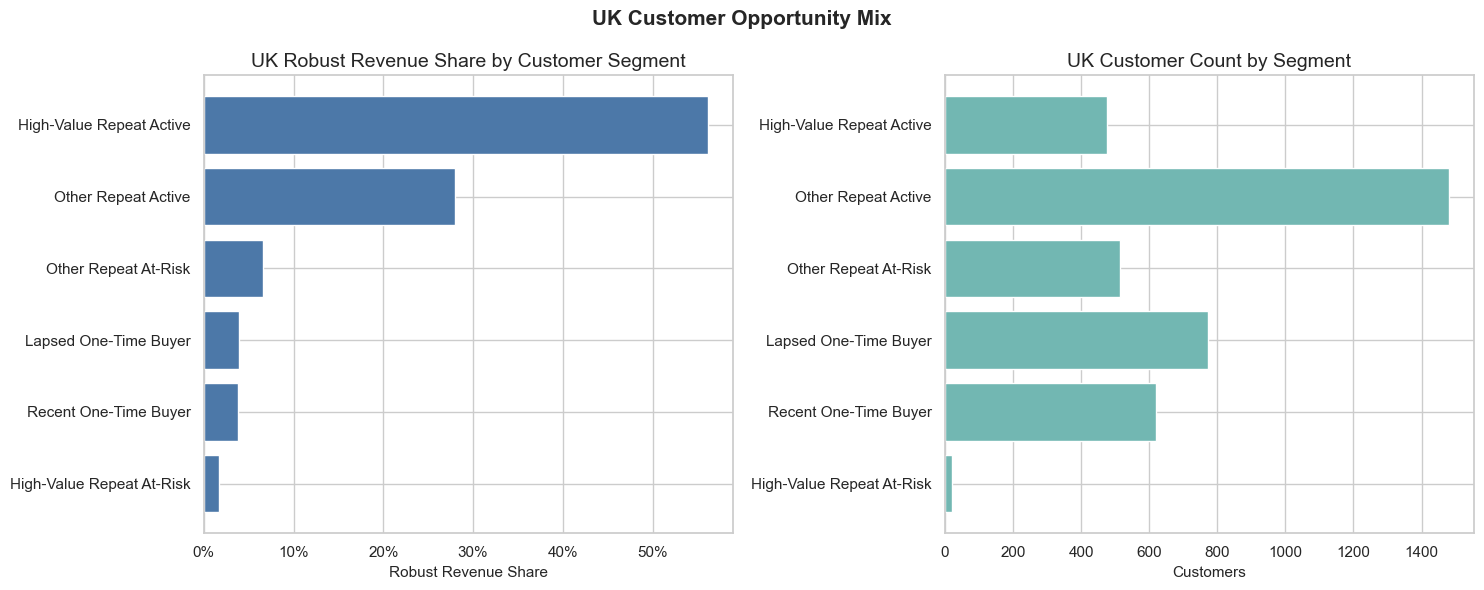

In [10]:
# UK 客户机会图
# -> 左边看不同客户分层贡献多少稳健收入
# -> 右边看每类客户的数量
# -> 两张小图放在一起，manager 可以同时看到价值和规模
uk_chart_path = PLOT_OUTPUT_DIR / 'uk_customer_opportunity.png'
segment_plot = uk_opportunity_segments.sort_values('robust_revenue')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(segment_plot['opportunity_segment'], segment_plot['robust_revenue_share'], color='#4C78A8')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].set_title('UK Robust Revenue Share by Customer Segment')
axes[0].set_xlabel('Robust Revenue Share')

axes[1].barh(segment_plot['opportunity_segment'], segment_plot['customer_count'], color='#72B7B2')
axes[1].set_title('UK Customer Count by Segment')
axes[1].set_xlabel('Customers')

fig.suptitle('UK Customer Opportunity Mix', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig(uk_chart_path, dpi=180, bbox_inches='tight')
plt.show()


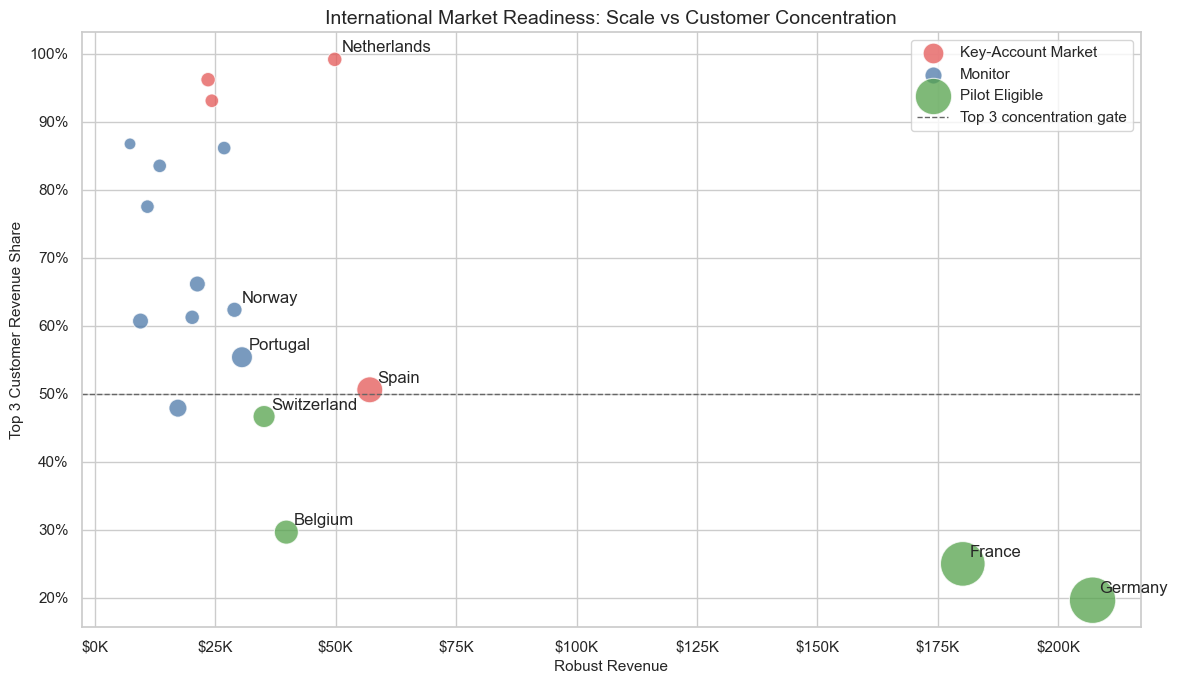

In [11]:
# 国际市场准备度图
# -> 横轴看稳健收入规模
# -> 纵轴看 Top 3 客户集中度，越低说明收入越不依赖少数客户
# -> 气泡大小表示客户数，方便同时看规模、广度和风险
market_chart_path = PLOT_OUTPUT_DIR / 'international_market_readiness.png'
plot_frame = international_market_scorecard.loc[international_market_scorecard['customer_count'].ge(5)]
color_map = {'Pilot Eligible': '#54A24B', 'Monitor': '#4C78A8', 'Key-Account Market': '#E45756'}

fig, ax = plt.subplots(figsize=(12, 7))
for status, group in plot_frame.groupby('pilot_status'):
    ax.scatter(
        group['robust_revenue'],
        group['top3_customer_share'],
        s=group['customer_count'] * 12,
        alpha=0.75,
        label=status,
        color=color_map[status],
        edgecolor='white',
        linewidth=0.8,
    )

labels = plot_frame.nlargest(8, 'robust_revenue')
for _, row in labels.iterrows():
    ax.annotate(row['Country'], (row['robust_revenue'], row['top3_customer_share']), xytext=(5, 5), textcoords='offset points')

ax.axhline(0.50, color='#666666', linestyle='--', linewidth=1, label='Top 3 concentration gate')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x / 1_000:,.0f}K'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('International Market Readiness: Scale vs Customer Concentration')
ax.set_xlabel('Robust Revenue')
ax.set_ylabel('Top 3 Customer Revenue Share')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(market_chart_path, dpi=180, bbox_inches='tight')
plt.show()


## 9. Decision Memo and Output Export

The following cell exports all decision tables and generates the manager-facing Markdown memo from the actual calculations. The PDF version is created after the notebook finishes running.


In [12]:
# 导出结果表
# -> 所有表都来自上面的真实计算
# -> 不覆盖 Week 1 / Week 2 文件
output_paths = {
    'data_risk_log': save_csv(data_risk_log, 'data_risk_log.csv'),
    'uk_customer_opportunity_segments': save_csv(uk_opportunity_segments, 'uk_customer_opportunity_segments.csv'),
    'uk_high_value_behavior_profile': save_csv(uk_high_value_behavior_profile, 'uk_high_value_behavior_profile.csv'),
    'uk_potential_customer_scorecard': save_csv(uk_potential_customer_scorecard, 'uk_potential_customer_scorecard.csv'),
    'uk_potential_score_backtest': save_csv(uk_potential_score_backtest, 'uk_potential_score_backtest.csv'),
    'international_market_scorecard': save_csv(international_market_scorecard, 'international_market_scorecard.csv'),
    'international_addressability_checklist': save_csv(international_addressability_checklist, 'international_addressability_checklist.csv'),
    'strategy_comparison': save_csv(strategy_comparison, 'strategy_comparison.csv'),
    'decision_stage_plan': save_csv(decision_stage_plan, 'decision_stage_plan.csv'),
    'future_measurement_data': save_csv(future_measurement_data, 'future_measurement_data.csv'),
}

# 这里取 memo 需要的关键数字。所有数字仍然保留在 notebook 的结果表里，便于复查来源。
uk_total_robust = current_uk_snapshot['robust_revenue'].sum()
uk_total_raw = current_uk_snapshot['raw_revenue'].sum()
uk_share_of_global = uk_total_raw / order_summary['raw_revenue'].sum()
high_active_row = uk_opportunity_segments.loc[
    uk_opportunity_segments['opportunity_segment'].eq('High-Value Repeat Active')
].iloc[0]
high_potential_summary = (
    current_uk_potential
    .groupby('potential_tier', as_index=False)
    .agg(customer_count=('CustomerID', 'nunique'), robust_revenue=('robust_revenue', 'sum'))
)
high_potential_row = high_potential_summary.loc[
    high_potential_summary['potential_tier'].eq('High Potential')
].iloc[0]

backtest_average = (
    uk_potential_score_backtest
    .groupby('potential_tier', as_index=False)
    .agg(
        average_repeat_purchase_rate_90d=('repeat_purchase_rate_90d', 'mean'),
        average_next90_robust_revenue_per_customer=('next90_robust_revenue_per_customer', 'mean'),
    )
)
backtest_high = backtest_average.loc[backtest_average['potential_tier'].eq('High Potential')].iloc[0]
backtest_standard = backtest_average.loc[backtest_average['potential_tier'].eq('Standard Potential')].iloc[0]

pilot_countries = candidate_markets['Country'].tolist()
pilot_country_text = ', '.join(pilot_countries) if pilot_countries else 'No country currently passes the data-only pilot gates'

# Memo 只保留管理层需要的结论、证据、风险和下一步，不把 notebook 中所有过程重复写进去。
memo_path = WEEK3_ROOT / 'Week3_Decision_Memo.md'
memo = '\n'.join([
    '# Week 3 Decision Memo: UK Growth and International Pilot Decision',
    '',
    '## Recommendation',
    '',
    'Adopt a **staged hybrid approach** for the next 90 days: protect and develop the UK customer base first, while preparing limited pilots in the strongest data-qualified international markets. Do not scale international investment until customer breadth and operational readiness are confirmed.',
    '',
    '## Why This Is the Recommended Direction',
    '',
    f'- The UK contributes **{format_percent(uk_share_of_global)}** of raw revenue in the complete analysis period. It is the current revenue base, so an international-only strategy would create unnecessary risk.',
    f"- **High-Value Repeat Active** customers account for **{int(high_active_row['customer_count']):,} customers** and **{format_percent(high_active_row['robust_revenue_share'])}** of UK robust revenue. This is the first group to protect.",
    f"- The UK opportunity is not limited to retention. The scorecard identifies **{int(high_potential_row['customer_count']):,} High Potential customers** whose recent activity, order frequency, robust AOV, and product breadth resemble positive high-value behaviors.",
    f"- In two historical 90-day checks, High Potential customers averaged a **{format_percent(backtest_high['average_repeat_purchase_rate_90d'])}** repeat-purchase rate, compared with **{format_percent(backtest_standard['average_repeat_purchase_rate_90d'])}** for Standard Potential customers. This supports using the rule-based score as a prioritization aid, not as a causal model.",
    f'- The leading data-qualified international pilot markets are: **{pilot_country_text}**. Their selection is based on customer breadth, repeat behavior, revenue evidence, active-month continuity, and concentration safety rather than revenue rank alone.',
    '',
    '![UK Customer Opportunity](outputs/plots/uk_customer_opportunity.png)',
    '',
    '## International Market Readiness',
    '',
    'The market screen adapts a simplified MARACA lens: Market Availability, Real-Time Analytics, Customer Addressability, and Risk. Customer Addressability remains a required business review because it cannot be inferred from transaction records alone. A country is not treated as scalable merely because it has high revenue. Markets driven by a small number of customers are classified as Key-Account Markets or Monitor markets instead of broad expansion targets.',
    '',
    '![International Market Readiness](outputs/plots/international_market_readiness.png)',
    '',
    '## 90-Day Stage Gates',
    '',
    '1. **Days 0-30:** Use the UK segment and potential-customer outputs to protect high-value repeat customers, prioritize at-risk customers, and develop High Potential customers.',
    '2. **Days 31-60:** Complete localization, payment, pricing, tax/logistics, and support checks for the leading pilot countries.',
    '3. **Days 61-90:** Continue only limited pilots that retain broad customer evidence and acceptable concentration. Do not approve scaled investment before finance and operations provide margin, acquisition-cost, shipping, discount, and return data.',
    '',
    '## Important Limits',
    '',
    '- December 2011 is incomplete and excluded from scored trends and comparisons.',
    '- Bulk orders are valid sales. They are retained in raw revenue and excluded only from the robust sensitivity view.',
    '- Historical customer revenue is a spend proxy, not profit or true lifetime value.',
    '- The current data cannot estimate an optimal country budget. A future ROI model requires: country-week marketing spend, traffic, conversion, acquisition source, margin, shipping, discount, and return data.',
])
memo_path.write_text(memo, encoding='utf-8')

print('Exported decision tables:')
for name, path in output_paths.items():
    print(f'- {name}: {path.relative_to(PROJECT_ROOT)}')
print(f'- memo: {memo_path.relative_to(PROJECT_ROOT)}')


Exported decision tables:
- data_risk_log: week3/outputs/forms/data_risk_log.csv
- uk_customer_opportunity_segments: week3/outputs/forms/uk_customer_opportunity_segments.csv
- uk_high_value_behavior_profile: week3/outputs/forms/uk_high_value_behavior_profile.csv
- uk_potential_customer_scorecard: week3/outputs/forms/uk_potential_customer_scorecard.csv
- uk_potential_score_backtest: week3/outputs/forms/uk_potential_score_backtest.csv
- international_market_scorecard: week3/outputs/forms/international_market_scorecard.csv
- international_addressability_checklist: week3/outputs/forms/international_addressability_checklist.csv
- strategy_comparison: week3/outputs/forms/strategy_comparison.csv
- decision_stage_plan: week3/outputs/forms/decision_stage_plan.csv
- future_measurement_data: week3/outputs/forms/future_measurement_data.csv
- memo: week3/Week3_Decision_Memo.md


## 10. Analytical Conclusion

The evidence should support a staged hybrid recommendation: defend and develop the broad UK revenue base, use behavioral evidence to prioritize UK customers with unrealized potential, and validate only the strongest international candidates after non-data operational readiness checks are complete.
